In [1]:
import pandas as pd

samples = pd.read_parquet("../data/processed/tidy_samples.parquet")
samples = samples.sort_values(["activity_id", "timestamp"]).reset_index(drop=True)
print(samples.shape)

(1325123, 9)


In [2]:
start = samples.groupby("activity_id")["timestamp"].transform("min")
samples["elapsed_s"] = (samples["timestamp"] - start).dt.total_seconds()

In [3]:
samples["elapsed_s"].describe()

count    1.325123e+06
mean     2.393508e+03
std      2.443427e+03
min      0.000000e+00
25%      8.290000e+02
50%      1.701000e+03
75%      3.013000e+03
max      1.972300e+04
Name: elapsed_s, dtype: float64

In [4]:
no_cadence = samples["cadence"].isna() | (samples["cadence"] == 0)
no_speed   = samples["speed_ms"].isna()
first_60   = samples["elapsed_s"] < 60

for name, mask in [("cadence missing/0", no_cadence),
                   ("speed missing", no_speed),
                   ("first 60 s", first_60)]:
    print(f"{name:20s} {mask.sum():>9,} rows  ({mask.mean():.1%})")

cadence missing/0       27,175 rows  (2.1%)
speed missing               53 rows  (0.0%)
first 60 s              24,108 rows  (1.8%)


In [5]:
print(samples.loc[no_cadence, "speed_ms"].describe(percentiles=[.5, .9, .99]))
print(samples.loc[~no_cadence, "speed_ms"].quantile([.001, .01, .05]))

count    27143.000000
mean         1.211377
std          1.929699
min          0.000000
50%          0.000000
90%          2.930000
99%          9.121220
max         14.416000
Name: speed_ms, dtype: float64
0.001    0.000
0.010    1.138
0.050    1.820
Name: speed_ms, dtype: float64


Matplotlib is building the font cache; this may take a moment.


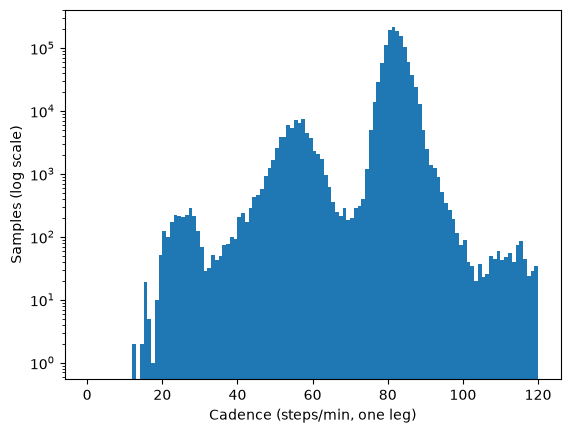

0.9900    4.348000
0.9990    5.160000
0.9999    6.188074
Name: speed_ms, dtype: float64


In [6]:
import matplotlib.pyplot as plt

cad = samples.loc[~no_cadence, "cadence"]
cad.plot.hist(bins=range(0, 121))
plt.yscale("log")
plt.xlabel("Cadence (steps/min, one leg)")
plt.ylabel("Samples (log scale)")
plt.show()

print(samples.loc[~no_cadence, "speed_ms"].quantile([.99, .999, .9999]))

In [7]:
walking = samples["cadence"] < 67
drop = no_cadence | no_speed | walking | first_60

print(f"walking (<67): {walking.sum():,}")
print(f"dropping total: {drop.sum():,} rows ({drop.mean():.1%})")

clean = samples.loc[~drop].copy()
print(clean.shape, clean["activity_id"].nunique(), "activities")

walking (<67): 93,089
dropping total: 116,383 rows (8.8%)
(1208740, 10) 408 activities


In [8]:
clean["dt"] = clean.groupby("activity_id")["timestamp"].diff().dt.total_seconds()
nominal = clean.groupby("activity_id")["dt"].transform("median")

clean["gap"] = clean["dt"] > 30
step = clean["dt"].clip(upper=nominal).fillna(0)
clean["moving_s"] = step.groupby(clean["activity_id"]).cumsum()

In [9]:
print(clean["gap"].sum(), "gaps in", clean.loc[clean["gap"], "activity_id"].nunique(), "activities")
clean.groupby("activity_id")["moving_s"].max().sort_values().tail(3)

844 gaps in 227 activities


activity_id
19272914242    10895.0
17414594839    13198.0
16663372714    13635.0
Name: moving_s, dtype: float64

In [10]:
summary = pd.read_parquet("../data/processed/activity_summary.parquet")
summary["qc_moving_s"] = summary["wall_clock_s"] - summary["paused_s"]

surviving = clean.groupby("activity_id")["moving_s"].max()
retained = surviving / summary.set_index("activity_id")["qc_moving_s"]

keep_ids = surviving[surviving >= 600].index
clean = clean[clean["activity_id"].isin(keep_ids)].copy()
clean["retained"] = clean["activity_id"].map(retained)

print(f"kept {len(keep_ids)} of {surviving.size} activities, {len(clean):,} rows")
print(clean.groupby("activity_id")["retained"].first().describe())

kept 403 of 408 activities, 1,207,543 rows
count    403.000000
mean       0.922374
std        0.087311
min        0.157430
25%        0.914969
50%        0.952305
75%        0.969128
max        0.989005
Name: retained, dtype: float64


In [11]:
nominal_by_act = clean.groupby("activity_id")["dt"].median()
one_hz = nominal_by_act[nominal_by_act <= 1.5].index
clean["is_1hz"] = clean["activity_id"].isin(one_hz)

med5 = (clean.groupby("activity_id")["speed_ms"]
             .transform(lambda s: s.rolling(5, center=True, min_periods=1).median()))

clean["speed_filt"] = clean["speed_ms"].where(~clean["is_1hz"], med5)

changed = (clean["speed_ms"] - clean["speed_filt"]).abs()
print(f"{(changed > 0.5).sum():,} samples moved >0.5 m/s")
print(f"unfiltered activities (6 s sampling): {(~clean['is_1hz']).groupby(clean['activity_id']).first().sum()}")

1,159 samples moved >0.5 m/s
unfiltered activities (6 s sampling): 7
